First 5 rows of data:
   pages  deadline_days  rate_inr
0      5             14      8000
1     12              7     22000
2      3             21      5000
3      8              5     18000
4     15             10     28000

Basic statistics:
           pages  deadline_days      rate_inr
count  30.000000      30.000000     30.000000
mean    8.833333      10.933333  16833.333333
std     4.885470       5.777085   9715.197243
min     2.000000       4.000000   3500.000000
25%     5.000000       6.250000   8625.000000
50%     8.000000       9.500000  17500.000000
75%    12.000000      14.000000  22875.000000
max    20.000000      25.000000  38000.000000


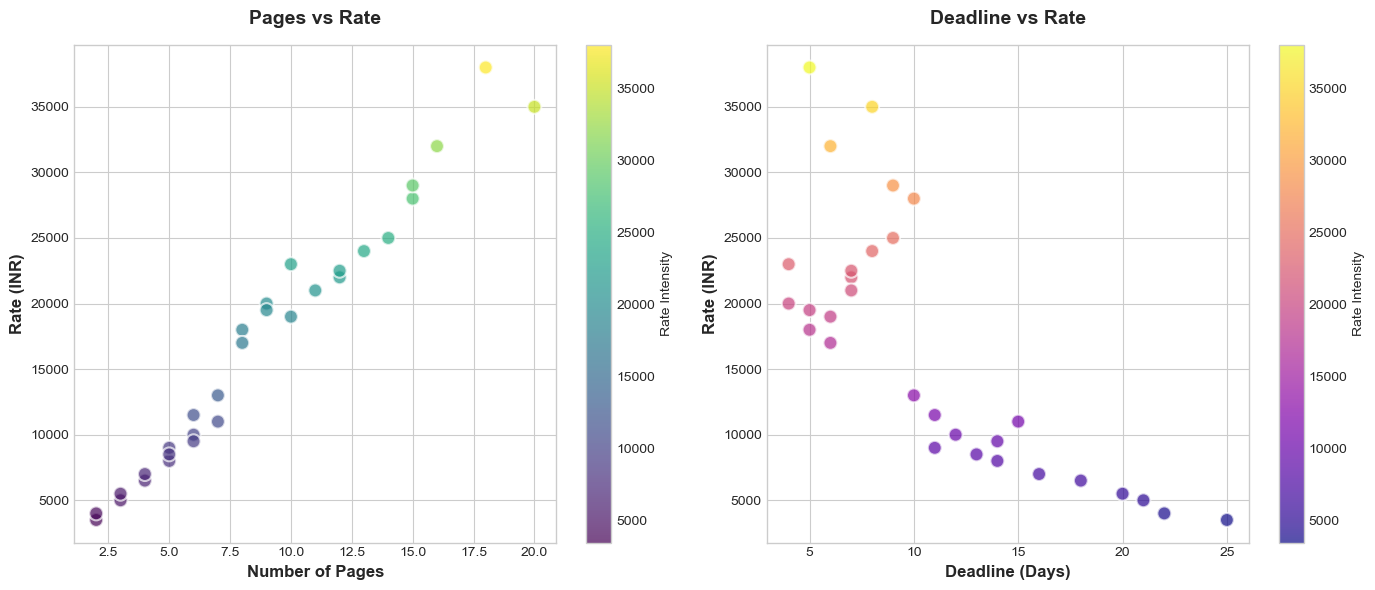


Model Parameters:
Coefficients: Pages = 1807.83, Deadline = -157.18
Intercept: 2401.86

Predictions vs Actual:
   Actual  Predicted
0   19500    17886.0
1    5500     4682.0
2   23000    19851.0
3   38000    34157.0
4   35000    37301.0
5   11000    12699.0

Model Accuracy (R² Score): 0.96

Priya's Question: 10-page website, 5-day deadline
Recommended Rate: ₹19,694


C:\Users\Suresh Mandamanedi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 2: Create the Dataset
data = {
    'pages': [5, 12, 3, 8, 15, 4, 10, 6, 20, 7,
              9, 2, 14, 5, 11, 3, 8, 18, 6, 13,
              4, 16, 7, 10, 2, 12, 5, 9, 15, 6],

    'deadline_days': [14, 7, 21, 5, 10, 18, 6, 12, 8, 15,
                      4, 25, 9, 11, 7, 20, 6, 5, 14, 8,
                      16, 6, 10, 4, 22, 7, 13, 5, 9, 11],

    'rate_inr': [8000, 22000, 5000, 18000, 28000, 6500, 19000, 10000, 35000, 11000,
                 20000, 3500, 25000, 9000, 21000, 5500, 17000, 38000, 9500, 24000,
                 7000, 32000, 13000, 23000, 4000, 22500, 8500, 19500, 29000, 11500]
}

df = pd.DataFrame(data)

# Step 3: Explore the Data
print("First 5 rows of data:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

# Step 4: Visualize the Data
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(df['pages'], df['rate_inr'],
                           c=df['rate_inr'], cmap='viridis', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axes[0].set_xlabel('Number of Pages', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rate (INR)', fontsize=12, fontweight='bold')
axes[0].set_title('Pages vs Rate', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(scatter1, ax=axes[0], label='Rate Intensity')

scatter2 = axes[1].scatter(df['deadline_days'], df['rate_inr'],
                           c=df['rate_inr'], cmap='plasma', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axes[1].set_xlabel('Deadline (Days)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rate (INR)', fontsize=12, fontweight='bold')
axes[1].set_title('Deadline vs Rate', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(scatter2, ax=axes[1], label='Rate Intensity')

plt.tight_layout()
plt.show()

# Step 5: Prepare Data for Training
X = df[['pages', 'deadline_days']]  # Two features now
y = df['rate_inr']

# Step 6: Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Check Model Parameters
print("\nModel Parameters:")
print(f"Coefficients: Pages = {model.coef_[0]:.2f}, Deadline = {model.coef_[1]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# Step 9: Make Predictions on Test Data
y_pred = model.predict(X_test)

print("\nPredictions vs Actual:")
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round()})
print(results)

# Step 10: Model Accuracy
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"\nModel Accuracy (R² Score): {score:.2f}")

# Step 11: Answer Priya's Question
new_project = [[10, 5]]  # 10 pages, 5 days deadline
predicted_rate = model.predict(new_project)
print(f"\nPriya's Question: 10-page website, 5-day deadline")
print(f"Recommended Rate: ₹{predicted_rate[0]:,.0f}")
